In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
ticker = 'AAPL'
df = yf.download(ticker,start='2022-01-01',end='2024-12-31',auto_adjust=True)
df.columns = df.columns.get_level_values(0)
df.reset_index(inplace=True)
print(df.shape)
print(df.columns.tolist())
df.head()

[*********************100%***********************]  1 of 1 completed

(752, 6)
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


Price,Date,Close,High,Low,Open,Volume
0,2022-01-03,177.939713,178.790267,173.735885,173.853197,104487900
1,2022-01-04,175.681381,178.848931,175.114350,178.545866,99310400
2,2022-01-05,171.008301,176.140896,170.734564,175.593422,94537600
3,2022-01-06,168.153580,171.379785,167.801630,168.837923,96904000
4,2022-01-07,168.319778,170.245725,167.205273,169.023678,86709100


In [8]:
df.info()
print()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    752 non-null    datetime64[s]
 1   Close   752 non-null    float64      
 2   High    752 non-null    float64      
 3   Low     752 non-null    float64      
 4   Open    752 non-null    float64      
 5   Volume  752 non-null    int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 35.4 KB



Price,Date,Close,High,Low,Open,Volume
count,752,752.000000,752.000000,752.000000,752.000000,7.520000e+02
mean,2023-07-02 08:58:05,175.768955,177.438736,173.893905,175.575642,6.811545e+07
min,2022-01-03 00:00:00,122.933563,125.637669,122.097738,123.907026,2.323470e+07
25%,2022-10-02 06:00:00,153.223553,154.919020,150.984460,152.691708,4.877432e+07
50%,2023-07-04 00:00:00,171.019333,172.033936,169.241081,170.672294,6.224455e+07
75%,2024-04-02 06:00:00,189.403484,190.807018,188.109984,189.285683,8.059140e+07
max,2024-12-30 00:00:00,257.375580,258.448740,255.994420,256.550862,3.186799e+08
std,NaN,29.352588,29.274174,29.298779,29.277642,2.834590e+07


In [9]:
df['Target'] = df['Close'].shift(-1)
df['MA_5'] = df['Close'].rolling(window=5).mean()
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['Daily_Return'] = df['Close'].pct_change()
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df[['Date','Open','High','Low','Close','Volume','MA_5','MA_10','Daily_Return','Target']].head()

Price,Date,Open,High,Low,Close,Volume,MA_5,MA_10,Daily_Return,Target
0,2022-01-14,167.508323,169.893760,167.263914,169.199646,80440800,169.729517,170.975034,0.005111,166.002777
1,2022-01-18,167.674528,168.681493,165.621499,166.002777,90956700,169.262210,169.781340,-0.018894,162.512604
2,2022-01-19,166.198300,167.254149,162.229096,162.512604,94815000,167.531790,168.464462,-0.021025,160.831085
3,2022-01-20,163.245850,165.885468,160.508463,160.831085,91420500,165.377084,167.446741,-0.010347,158.778046
4,2022-01-21,160.743091,162.610381,158.670505,158.778046,122848900,163.464832,166.509187,-0.012765,158.005707


In [10]:
features = ['Open','High','Low','Volume','MA_5','MA_10','Daily_Return']
X = df[features].values
y = df['Target'].values
dates = df['Date'].values
X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X,y,dates,test_size=0.2,shuffle=False
)
print(f'Training samples:{len(X_train)}')
print(f'Testing  samples:{len(X_test)}')

Training samples:593
Testing  samples:149


In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train,y_train)
lr_preds = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test,lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test,lr_preds))
lr_r2 = r2_score(y_test,lr_preds)
print('Linear Regression Performance')
print(f'MAE:{lr_mae:.4f}')
print(f'RMSE:{lr_rmse:.4f}')
print(f'R²:{lr_r2:.4f}')

Linear Regression Performance
MAE:2.9048
RMSE:3.5817
R²:0.9305


In [12]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
rf_preds = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test,rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_preds))
rf_r2 = r2_score(y_test,rf_preds)
print('Random Forest Performance')
print(f'MAE:{rf_mae:.4f}')
print(f'RMSE:{rf_rmse:.4f}')
print(f'R²:{rf_r2:.4f}')

Random Forest Performance
MAE:30.5976
RMSE:33.3211
R²:-5.0116


In [13]:
metrics = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'MAE':[lr_mae,rf_mae],
    'RMSE':[lr_rmse,rf_rmse],
    'R²':[lr_r2,rf_r2]
})
print(metrics.to_string(index=False))

            Model       MAE      RMSE        R²
Linear Regression  2.904834  3.581661  0.930542
    Random Forest 30.597573 33.321090 -5.011634


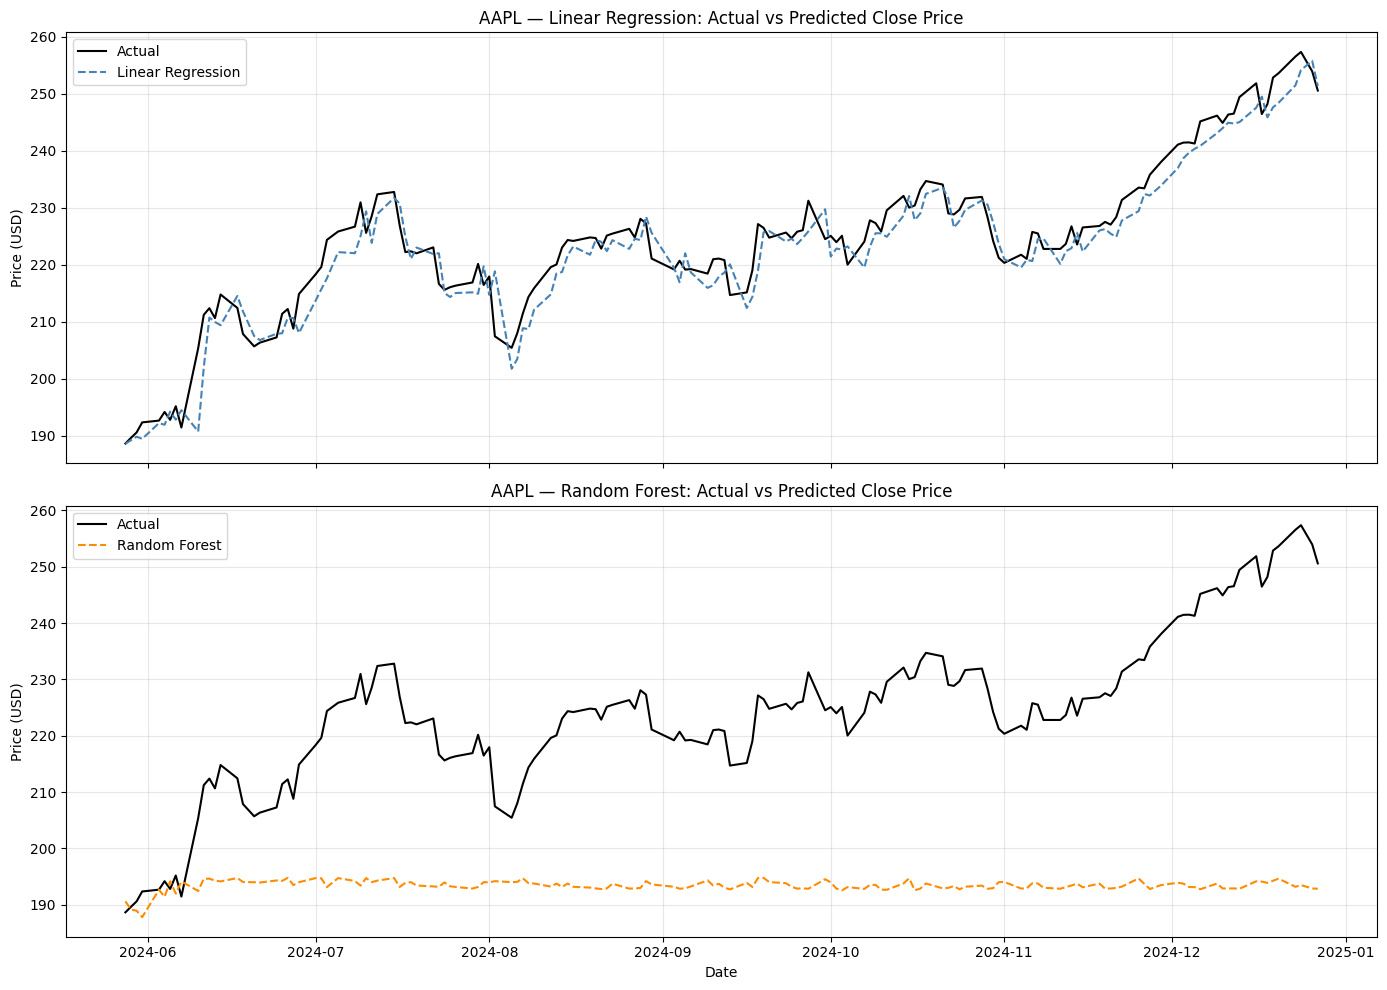

In [14]:
fig , axes = plt.subplots(2,1,figsize=(14,10),sharex=True)
axes[0].plot(dates_test,y_test,label='Actual',color='black',linewidth=1.5)
axes[0].plot(dates_test,lr_preds,label='Linear Regression',color='steelblue',linestyle='--',linewidth=1.5)
axes[0].set_title(f'{ticker} — Linear Regression: Actual vs Predicted Close Price')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True,alpha=0.3)
axes[1].plot(dates_test,y_test,label='Actual',color='black',linewidth=1.5)
axes[1].plot(dates_test,rf_preds,label='Random Forest',color='darkorange',linestyle='--',linewidth=1.5)
axes[1].set_title(f'{ticker} — Random Forest: Actual vs Predicted Close Price')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

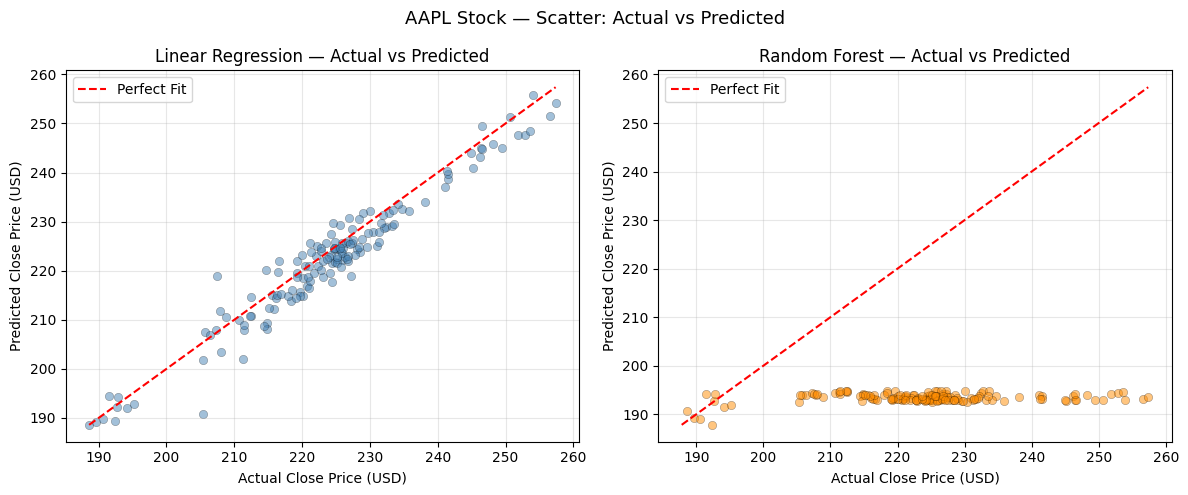

In [15]:
fig , axes = plt.subplots(1,2,figsize=(12,5))
for ax , preds , label , color in zip(
    axes,
    [lr_preds,rf_preds],
    ['Linear Regression','Random Forest'],
    ['steelblue','darkorange']
):
    ax.scatter(y_test,preds,alpha=0.5,color=color,edgecolors='k',linewidths=0.3)
    min_val = min(y_test.min(),preds.min())
    max_val = max(y_test.max(),preds.max())
    ax.plot([min_val,max_val],[min_val,max_val],'r--',linewidth=1.5,label='Perfect Fit')
    ax.set_title(f'{label} — Actual vs Predicted')
    ax.set_xlabel('Actual Close Price (USD)')
    ax.set_ylabel('Predicted Close Price (USD)')
    ax.legend()
    ax.grid(True,alpha=0.3)
plt.suptitle(f'{ticker} Stock — Scatter: Actual vs Predicted',fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\siddi\AppData\Local\Temp\ipykernel_17320\2981484644.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df,x='Importance',y='Feature',palette='viridis')


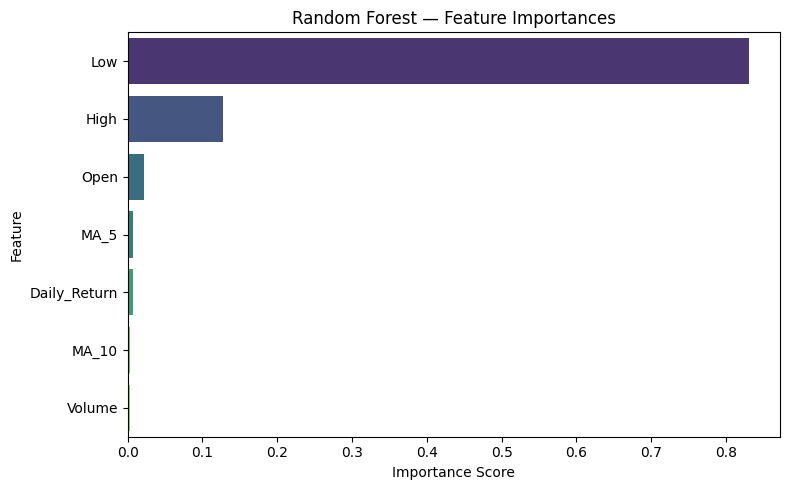

In [16]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature':features,'Importance':importances}).sort_values('Importance',ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=feat_df,x='Importance',y='Feature',palette='viridis')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()